## Project Overview

This notebook builds a binary classifier to predict passenger survival on the Titanic.
The dataset contains 891 records with 5 features: `Sex`, `Age`, `Pclass`, `Embarked`, and `Survived`.

The pipeline follows these steps:
1. Explore the data (EDA)
2. Clean and encode the features (preprocessing)
3. Find the best tree depth using a validation set
4. Evaluate the final model on the test set

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading

I load the dataset using `PassengerId` as the index since it's just an ID — it carries no useful
information for prediction.

In [13]:
dataset = pd.read_csv(r"C:\Users\Usuario\Desktop\titanic_sub.csv", index_col='PassengerId')

## 2. Exploratory Data Analysis

A few things stand out right away:

- `Age` is missing in about 20% of rows — too many to drop, so I'll need to impute them.
- `Embarked` only has 2 missing values — easy to handle.
- The survival rate is around 38%, so the dataset is somewhat imbalanced. Accuracy alone may not tell the full story.

In [14]:
print('shape:', dataset.shape)
print('\n Missing values:\n', dataset.isnull().sum())
print('\n Statistics: \n', dataset.describe())


shape: (891, 5)

 Missing values:
 Sex           0
Age         177
Pclass        0
Embarked      2
Survived      0
dtype: int64

 Statistics: 
               Age      Pclass    Survived
count  714.000000  891.000000  891.000000
mean    29.699118    2.308642    0.383838
std     14.526497    0.836071    0.486592
min      0.420000    1.000000    0.000000
25%     20.125000    2.000000    0.000000
50%     28.000000    3.000000    0.000000
75%     38.000000    3.000000    1.000000
max     80.000000    3.000000    1.000000


In [15]:
#General survived
dataset.Survived.value_counts(normalize = True).round(2)

Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Some clear patterns show up:

- **Sex**: women survived at a much higher rate than men.
- **Pclass**: 1st class passengers survived more than 3rd class.
- **Embarked**: passengers from Cherbourg (C) have a higher survival rate

All three variables look useful, so I'll keep them all as features.

In [16]:
for col in ['Sex','Pclass','Embarked']:
    print(f'\nSurvival rate per {col}')
    print(dataset.groupby(col)['Survived'].mean().round(2))


Survival rate per Sex
Sex
female    0.74
male      0.19
Name: Survived, dtype: float64

Survival rate per Pclass
Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

Survival rate per Embarked
Embarked
C    0.55
Q    0.39
S    0.34
Name: Survived, dtype: float64


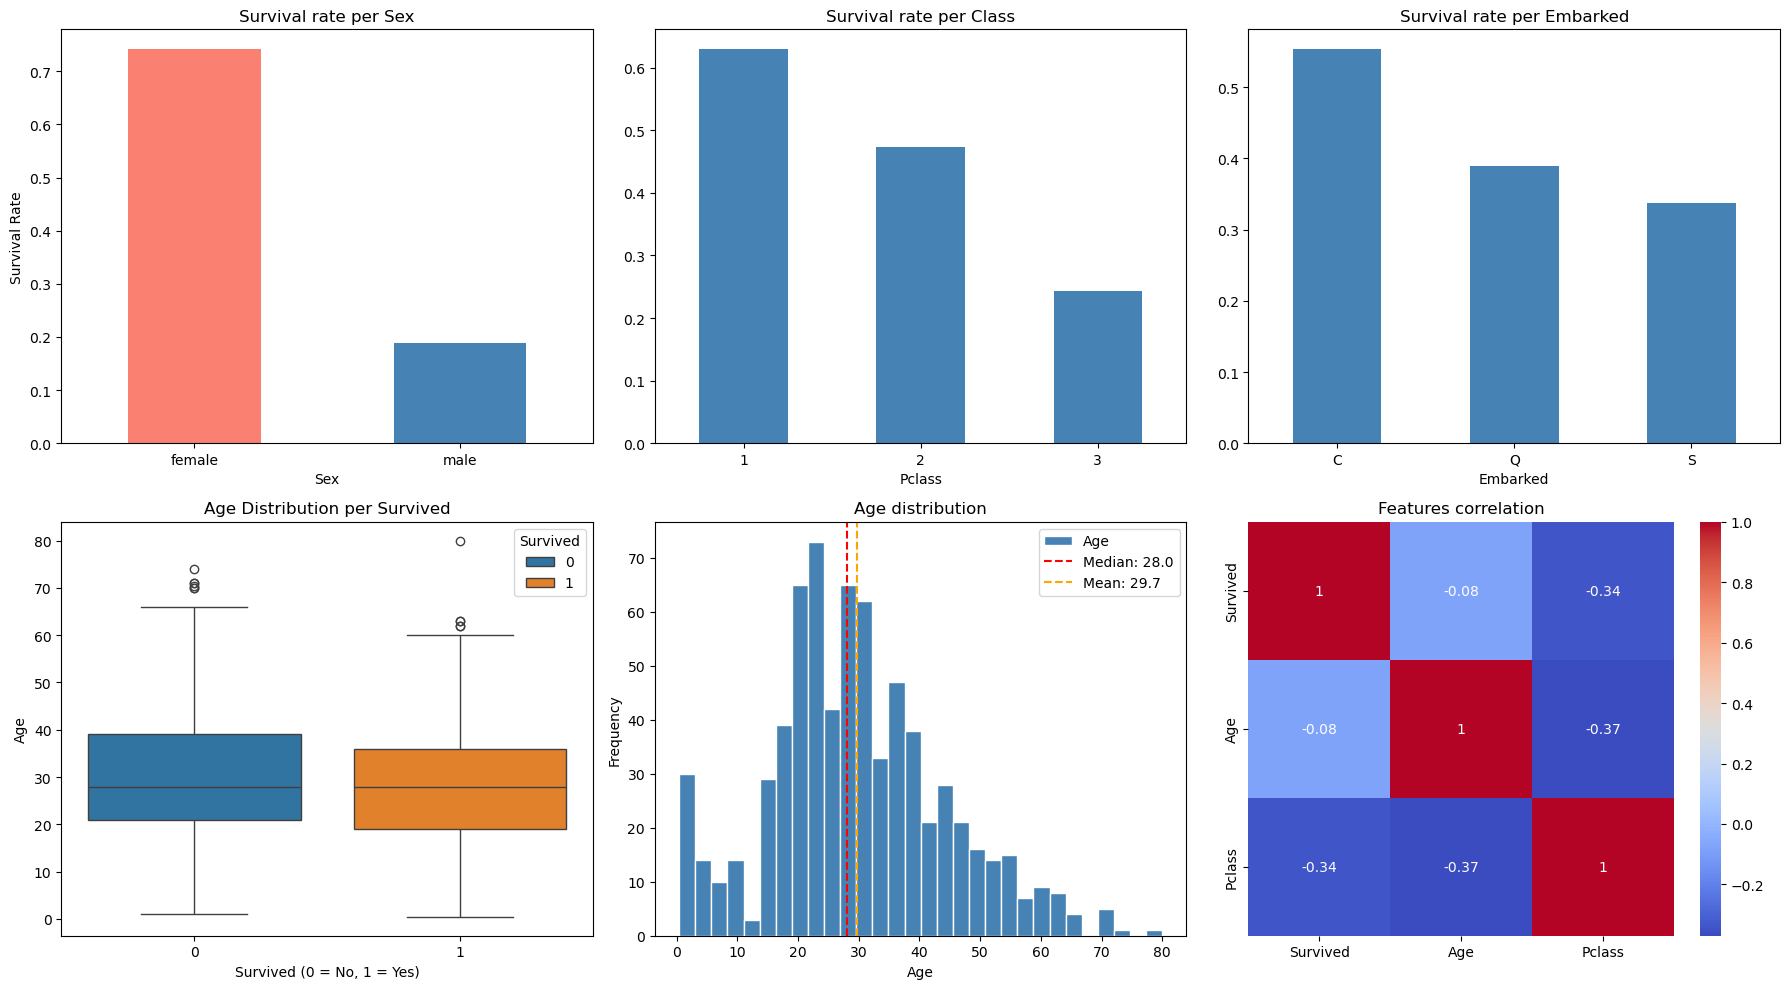

In [17]:
# EDA: Resuming plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Survival per sex
dataset.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0,0], color=['salmon', 'steelblue'])
axes[0,0].set_title('Survival rate per Sex')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].tick_params(axis='x', rotation=0)

# Survival per classe
dataset.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Survival rate per Class')
axes[0,1].tick_params(axis='x', rotation=0)

# Survival per Embarked
dataset.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Survival rate per Embarked')
axes[0,2].tick_params(axis='x', rotation=0)

# Age vs Survived 
sns.boxplot(data=dataset, x='Survived', y='Age', ax=axes[1,0], hue=dataset['Survived'])
axes[1,0].set_title('Age Distribution per Survived')
axes[1,0].set_xlabel('Survived (0 = No, 1 = Yes)')
axes[1,0].set_ylabel('Age')

# Distribution age (hist) 
dataset['Age'].dropna().plot(kind='hist', bins=30, ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].axvline(dataset['Age'].median(), color='red', linestyle='--', label=f"Median: {dataset['Age'].median():.1f}")
axes[1,1].axvline(dataset['Age'].mean(), color='orange', linestyle='--', label=f"Mean: {dataset['Age'].mean():.1f}")
axes[1,1].set_title('Age distribution')
axes[1,1].set_xlabel('Age')
axes[1,1].legend()

# Numeric features correlation
corr_cols = ['Survived', 'Age', 'Pclass']
sns.heatmap(dataset[corr_cols].corr().round(2), annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Features correlation')

plt.tight_layout()
plt.show()


**Visual observations:**

- Younger passengers, especially children, had a better chance of surviving.
- The age distribution is slightly right-skewed: the median (28) is lower than the mean (30).
  This is why I'll use the **median** to fill missing age values — it's less affected by the
  older passengers at the tail end of the distribution.
- `Pclass` has a noticeable negative correlation with survival (−0.34): lower class, lower survival.
- `Age` has a weaker correlation (−0.08): it matters, but less than sex or class.

In [18]:
X= dataset.drop(columns='Survived')
y = dataset.Survived

## 3. Train / Validation / Test Split

The data is split into **three sets**:

The reason for a separate validation set is simple: if I used the test set to choose
`max_depth`, the final score would be optimistic and unreliable. The test set has to
stay "unseen" until the very last step.

In [19]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 0)

In [20]:
num_col = ['Age', 'Pclass']
cat_col = ['Sex','Embarked']

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

col_trasf = ColumnTransformer(transformers=[
    ('num',num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

X_train = col_trasf.fit_transform(X_train)
X_val = col_trasf.transform (X_val)
X_test= col_trasf.transform (X_test)

## 4. Preprocessing

I use a `ColumnTransformer` to apply different steps to each type of feature:

- **`Age` and `Pclass`**: I fill any missing values with the **median** of the training set.
  I use the median instead of the mean because the age distribution is skewed —
  the mean would be pulled up by a few older passengers.
  `Pclass` has no missing values, but passing it through the numeric pipeline
  keeps the transformer consistent.

- **`Sex` and `Embarked`**: I fill the 2 missing values with the most frequent category,
  then apply `OneHotEncoder(drop='first')` to convert them to numbers.
  Dropping the first column avoids having redundant information.

One important detail: I call `.fit_transform()` only on `X_train`. This means the median
and mode are calculated from training data only, and then applied to validation and test.
If I had fit on the whole dataset, the model would have indirectly seen test data
during training — that's called **data leakage**.

In [21]:
#Finding the best depth
depths=[2,5,10,25, None]
best_depth = None
best_accuracy = 0

print(f"{'depth':>10}  {'acc_train'}  {'acc_val'}")
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=0)
    model.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_val = accuracy_score(y_val, model.predict(X_val))

    if acc_val > best_accuracy:
        best_accuracy = acc_val
        best_depth = depth
        
    label = depth if depth is not None else "max"
    print(f"{label:>10} | {acc_train:.4f} | {acc_val:.4f}")

print(f"\nBest depth: {best_depth}")  
print(f"Best accurate value: {best_accuracy}")  




     depth  acc_train  acc_val
         2 | 0.7904 | 0.7904
         5 | 0.8523 | 0.8024
        10 | 0.9062 | 0.7844
        25 | 0.9122 | 0.7784
       max | 0.9122 | 0.7784

Best depth: 5
Best accurate value: 0.8023952095808383


`max_depth=5` is selected because it achieves the highest validation accuracy (0.8024).
The growing gap between train and validation accuracy as depth increases is a classic sign
of **overfitting**: the model memorises training examples instead of generalising.
At `max_depth=10` and beyond, training accuracy reaches 0.91 but validation drops,
confirming that deeper trees are learning noise rather than real patterns.

Accuracy test: 0.8117

Confusion Matrix:


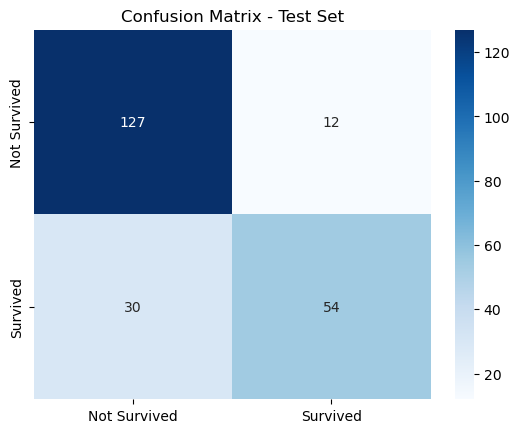


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.91      0.86       139
    Survived       0.82      0.64      0.72        84

    accuracy                           0.81       223
   macro avg       0.81      0.78      0.79       223
weighted avg       0.81      0.81      0.81       223



In [ ]:
import numpy as np
X_train_full = np.concatenate([X_train, X_val]) # → numpy.ndarray
y_train_full = pd.concat([y_train, y_val]) # → pandas.Series

# Model evaluation with the best depth
best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
best_model.fit(X_train_full, y_train_full) 
y_pred = best_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy test: {acc:.4f}')

# Confusion Matrix
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Test Set')
plt.show()

# Classification report (Precision, Recall, F1)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

## 6. Final Evaluation

**Test accuracy: 81.17%**

This is close to the validation accuracy (80.24%), so the model didn't overfit to the validation set —
a good sign.

Compared to the naive baseline of always predicting "Not Survived" (which would give ~62%),
81% is a real improvement. The model has clearly picked up on meaningful patterns.

**Confusion matrix:**

The model is better at identifying non-survivors (recall 0.91) than survivors (recall 0.64).
The most common mistake is predicting "Not Survived" for someone who actually survived —
30 false negatives vs 12 false positives — which makes sense given that survivors are the minority class.

The macro average F1-score is 0.79, meaning the model performs reasonably well on both
classes — not just the majority one.